In [5]:
from datasets import load_dataset, ClassLabel
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
from openai import OpenAI
from pydantic import BaseModel, Field
from enum import Enum
from typing import Literal
import json
import os
import json
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import defaultdict


In [2]:
dataset = load_dataset("ailsntua/QEvasion")

In [6]:
explicit_examples = []
general_examples = []
partial_examples = []
dodging_examples = []
implicit_examples = []
deflection_examples = []
declining_examples = []
ignorance_examples = []
clarification_examples = []

MAX_QUESTION_CHARS = 600
MAX_ANSWER_CHARS = 1300

for example in dataset["train"]:
    question_text = example["question"]
    answer_text = example["interview_answer"]

    if len(question_text) > MAX_QUESTION_CHARS:
        continue

    if len(answer_text) > MAX_ANSWER_CHARS:
        continue

    label = example["evasion_label"]

    if label == "Explicit" and len(explicit_examples) < 2:
        explicit_examples.append(example)

    elif label == "General" and len(general_examples) < 4:
        general_examples.append(example)

    elif label == "Partial/half-answer" and len(partial_examples) < 4:
        partial_examples.append(example)

    elif label == "Dodging" and len(dodging_examples) < 4:
        dodging_examples.append(example)

    elif label == "Implicit" and len(implicit_examples) < 4:
        implicit_examples.append(example)

    elif label == "Deflection" and len(deflection_examples) < 4:
        deflection_examples.append(example)

    elif label == "Declining to answer" and len(declining_examples) < 2:
        declining_examples.append(example)

    elif label == "Claims ignorance" and len(ignorance_examples) < 2:
        ignorance_examples.append(example)

    elif label == "Clarification" and len(clarification_examples) < 2:
        clarification_examples.append(example)

In [10]:
prompt_clarity = f"""
Task:
    Determine the clarity level of a politician's answer to a specific interview sub-question.

    You must assign exactly one of three classes:

    CLASS_1: Clear Reply
    - The answer clearly provides the requested information.
    - The answer directly answers the specific_sub_question.
    - The answer may be short, but it gives the information that was asked for.

    CLASS_2: Ambivalent
    - The answer engages with the topic of the question, but does not clearly provide the requested information.
    - The answer may be vague, indirect, incomplete, overly general, evasive, deflecting, dodging, implicit, or partial.
    - The answer is not a complete non-reply because it still says something related to the question.

    CLASS_3: Clear Non-Reply
    - The answer does not provide the requested information.
    - The answer clearly refuses to answer, claims not to know, says the question is unclear, or asks for clarification.

    Rules:
    - Focus on whether the interview_answer answers the specific_sub_question, not merely the original_interview_question.
    - If the answer directly gives the requested information, choose CLASS_1.
    - If the answer is related to the topic but does not clearly answer the specific_sub_question, choose CLASS_2.
    - If the answer refuses, claims ignorance, or asks for clarification, choose CLASS_3.
    - If the answer contains both a non-reply and some relevant information, choose CLASS_2 unless the relevant information clearly answers the specific_sub_question.
    - If uncertain between CLASS_1 and CLASS_2, choose CLASS_2.
    - If uncertain between CLASS_2 and CLASS_3, choose CLASS_2 only if the answer makes a real attempt to address the topic; otherwise choose CLASS_3.

    Return:
        - label: exactly one of CLASS_1, CLASS_2, or CLASS_3
        - confidence: an integer from 0 to 100 estimating confidence in the selected label

    Do not provide an explanation.

    You will receive:
    - original_interview_question
    - specific_sub_question
    - interview_answer
    - gpt3.5_summary
    - affirmative_questions

    Examples:

    original_interview_question: {explicit_examples[0]["interview_question"]}
    specific_sub_question: {explicit_examples[0]["question"]}
    interview_answer: {explicit_examples[0]["interview_answer"]}
    gpt3.5_summary: {explicit_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {explicit_examples[0].get("affirmative_questions", "")}
    Label: CLASS_1

    original_interview_question: {explicit_examples[1]["interview_question"]}
    specific_sub_question: {explicit_examples[1]["question"]}
    interview_answer: {explicit_examples[1]["interview_answer"]}
    gpt3.5_summary: {explicit_examples[1].get("gpt3.5_summary", "")}
    affirmative_questions: {explicit_examples[1].get("affirmative_questions", "")}
    Label: CLASS_1

    original_interview_question: {implicit_examples[0]["interview_question"]}
    specific_sub_question: {implicit_examples[0]["question"]}
    interview_answer: {implicit_examples[0]["interview_answer"]}
    gpt3.5_summary: {implicit_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {implicit_examples[0].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {dodging_examples[0]["interview_question"]}
    specific_sub_question: {dodging_examples[0]["question"]}
    interview_answer: {dodging_examples[0]["interview_answer"]}
    gpt3.5_summary: {dodging_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {dodging_examples[0].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {general_examples[0]["interview_question"]}
    specific_sub_question: {general_examples[0]["question"]}
    interview_answer: {general_examples[0]["interview_answer"]}
    gpt3.5_summary: {general_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {general_examples[0].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {deflection_examples[0]["interview_question"]}
    specific_sub_question: {deflection_examples[0]["question"]}
    interview_answer: {deflection_examples[0]["interview_answer"]}
    gpt3.5_summary: {deflection_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {deflection_examples[0].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {partial_examples[0]["interview_question"]}
    specific_sub_question: {partial_examples[0]["question"]}
    interview_answer: {partial_examples[0]["interview_answer"]}
    gpt3.5_summary: {partial_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {partial_examples[0].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {declining_examples[0]["interview_question"]}
    specific_sub_question: {declining_examples[0]["question"]}
    interview_answer: {declining_examples[0]["interview_answer"]}
    gpt3.5_summary: {declining_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {declining_examples[0].get("affirmative_questions", "")}
    Label: CLASS_3

    original_interview_question: {ignorance_examples[0]["interview_question"]}
    specific_sub_question: {ignorance_examples[0]["question"]}
    interview_answer: {ignorance_examples[0]["interview_answer"]}
    gpt3.5_summary: {ignorance_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {ignorance_examples[0].get("affirmative_questions", "")}
    Label: CLASS_3

    original_interview_question: {clarification_examples[0]["interview_question"]}
    specific_sub_question: {clarification_examples[0]["question"]}
    interview_answer: {clarification_examples[0]["interview_answer"]}
    gpt3.5_summary: {clarification_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {clarification_examples[0].get("affirmative_questions", "")}
    Label: CLASS_3
""".strip()

def get_label(class_name: str) -> str:
    labels = {
        "CLASS_1": "Clear Reply",
        "CLASS_2": "Ambivalent",
        "CLASS_3": "Clear Non-Reply",
    }
    return labels[class_name]

class ClassificationResult(BaseModel):
    label: Literal["CLASS_1", "CLASS_2", "CLASS_3"]
    confidence: int = Field(ge=0, le=100)

In [ ]:
output_file = "clarity.jsonl"
processed_indices = set()


client = OpenAI(api_key=api_key)

if os.path.exists(output_file):
    with open(output_file, "r", encoding="utf-8") as file:
        for line in file:
            saved_result = json.loads(line)
            processed_indices.add(saved_result["dataset_index"])


for index, train in enumerate(dataset["train"].select(range(500,1000)),start=500):

    if index in processed_indices:
        continue

    if train in clarification_examples:
        continue
    if train in declining_examples:
        continue
    if train in ignorance_examples:
        continue
    if train in explicit_examples:
        continue
    if train in general_examples:
        continue
    if train in partial_examples:
        continue
    if train in dodging_examples:
        continue
    if train in implicit_examples:
        continue
    if train in deflection_examples:
        continue

    messages = [
        {
            "role": "developer",
            "content": prompt_clarity
        },
        {
            "role": "user",
            "content": f"""
original_interview_question: {train["interview_question"]}
specific_sub_question: {train["question"]}
interview_answer: {train["interview_answer"]}
gpt3.5_summary: {train.get("gpt3.5_summary", "")}
affirmative_questions: {train.get("affirmative_questions", "")}
""".strip()
        }
    ]

    try:
        response = client.responses.parse(
            model="gpt-5.4",
            input=messages,
            text_format=ClassificationResult,
            store=False,
        )

        result = response.output_parsed

        saved_result = {
            "dataset_index": index,
            "question": train["interview_question"],
            "specific_sub_question": train["question"],
            "answer": train["interview_answer"],
            "interview_answer": train["interview_answer"],
            "gpt3.5_summary": train.get("gpt3.5_summary", ""),
            "affirmative_questions": train.get("affirmative_questions", ""),
            "true_label_evasion": train["evasion_label"],
            "true_label_clarity": train["clarity_label"],
            "predicted_label_evasion":None,
            "predicted_label_clarity": get_label(result.label),
            "confidence": result.confidence
        }

        
        with open(output_file, "a", encoding="utf-8") as file:
            file.write(json.dumps(saved_result, ensure_ascii=False) + "\n")

        processed_indices.add(index)
        print(f"saved {index} / 500) ")
    except Exception as error:
        print(f"Stopped at dataset index {index}: {error}")
        break

saved 0 / 500) 
saved 1 / 500) 
saved 4 / 500) 
saved 5 / 500) 
saved 6 / 500) 
saved 7 / 500) 
saved 8 / 500) 
saved 9 / 500) 
saved 12 / 500) 
saved 13 / 500) 
saved 14 / 500) 
saved 23 / 500) 
saved 24 / 500) 
saved 28 / 500) 
saved 30 / 500) 
saved 33 / 500) 
saved 34 / 500) 
saved 35 / 500) 
saved 36 / 500) 
saved 37 / 500) 
saved 38 / 500) 
saved 39 / 500) 
saved 40 / 500) 
saved 41 / 500) 
saved 42 / 500) 
saved 44 / 500) 
saved 45 / 500) 
saved 46 / 500) 
saved 48 / 500) 
saved 49 / 500) 
saved 50 / 500) 
saved 51 / 500) 
saved 53 / 500) 
saved 54 / 500) 
saved 56 / 500) 
saved 57 / 500) 
saved 58 / 500) 
saved 59 / 500) 
saved 60 / 500) 
saved 61 / 500) 
saved 62 / 500) 
saved 63 / 500) 
saved 65 / 500) 
saved 66 / 500) 
saved 67 / 500) 
saved 68 / 500) 
saved 69 / 500) 
saved 70 / 500) 
saved 71 / 500) 
saved 72 / 500) 
saved 73 / 500) 
saved 74 / 500) 
saved 75 / 500) 
saved 76 / 500) 
saved 77 / 500) 
saved 78 / 500) 
saved 79 / 500) 
saved 80 / 500) 
saved 81 / 500) 
saved

Total clarity rows: 472

Clarity Macro F1:
0.6560509412988434

Clarity Weighted F1:
0.7190189410931409

Clarity Micro F1:
0.711864406779661

Classification report:
                 precision    recall  f1-score   support

     Ambivalent       0.75      0.69      0.72       242
Clear Non-Reply       0.38      0.58      0.46        48
    Clear Reply       0.80      0.77      0.79       182

       accuracy                           0.71       472
      macro avg       0.64      0.68      0.66       472
   weighted avg       0.73      0.71      0.72       472

[[167  41  34]
 [ 18  28   2]
 [ 37   4 141]]


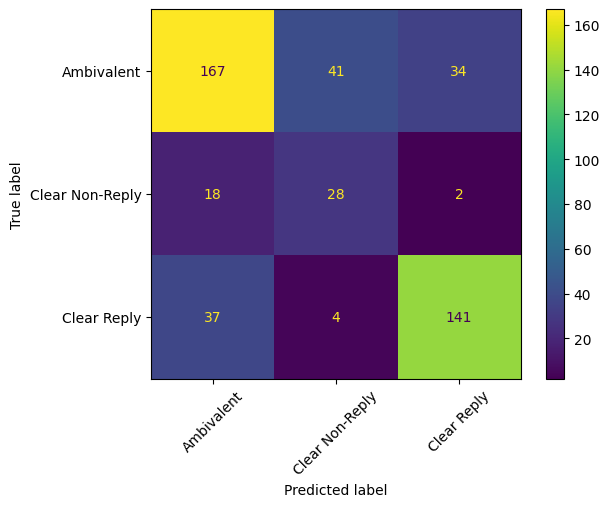

In [14]:
file_path = "clarity.jsonl"  # change this to your actual jsonl filename

y_true_clarity = []
y_pred_clarity = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        true_label = row.get("true_label_clarity")
        predicted_label = row.get("predicted_label_clarity")

        # skip broken / unfinished rows
        if true_label is None or predicted_label is None:
            continue

        y_true_clarity.append(true_label)
        y_pred_clarity.append(predicted_label)

print("Total clarity rows:", len(y_true_clarity))

print("\nClarity Macro F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="macro"))

print("\nClarity Weighted F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="weighted"))

print("\nClarity Micro F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="micro"))

print("\nClassification report:")
print(classification_report(y_true_clarity, y_pred_clarity))

labels = ["Ambivalent", "Clear Non-Reply", "Clear Reply"]

cm = confusion_matrix(y_true_clarity, y_pred_clarity, labels=labels)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.show()

In [15]:
prompt_explicit_clear_reply_verifier = f"""
Task:
    Determine whether the politician's answer explicitly answers the specific sub-question.

    This is a verification step.
    The answer was previously classified as Clear Reply.
    Your job is to check whether it is truly explicit.

    Return CLASS_1 if the answer is an explicit Clear Reply.
    Return CLASS_2 if the answer is not an explicit Clear Reply.

    CLASS_1: Explicit
    - The answer directly provides the information requested by the specific_sub_question.
    - The requested information is stated clearly and explicitly.
    - The answer does not require inference.
    - The answer is not just related to the topic; it actually answers the specific_sub_question.

    CLASS_2: Not Explicit 
    - The answer does not directly provide the requested information.
    - The answer is vague, partial, general, implicit, indirect, dodging, deflecting, refusing, claiming ignorance, or asking for clarification.
    - If the answer only talks around the topic, choose CLASS_2.
    - If the answer requires inference, choose CLASS_2.
    - If the answer gives only part of the requested information, choose CLASS_2.
    - If uncertain, choose CLASS_2.

    Rules:
    - Focus on the specific_sub_question, not just the original_interview_question.
    - Choose CLASS_1 only when the answer clearly, directly, and explicitly answers the specific_sub_question.
    - Relevant information alone is not enough for CLASS_1.
    - Implied answers are not CLASS_1.
    - Partial answers are not CLASS_1.
    - Return:
        - label: exactly CLASS_1 or CLASS_2
        - confidence: integer from 0 to 100
    - Do not provide an explanation.

    You will receive:
    - original_interview_question
    - specific_sub_question
    - interview_answer
    - gpt3.5_summary
    - affirmative_questions
""".strip()

def get_label_yesno(class_name: str) -> str:
    labels = {
        "CLASS_1": "Explicit",
        "CLASS_2": None,
    }
    return labels[class_name]
class ClassificationResult_yesno(BaseModel):
    label: Literal["CLASS_1", "CLASS_2"]
    confidence: int = Field(ge=0, le=100)

In [16]:
file_path = "clarity.jsonl"
output_file = "clear_reply.jsonl"

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        predicted_label = row.get("predicted_label_clarity")

        # Only verify examples that were predicted as Clear Reply
        if predicted_label != "Clear Reply":
            continue

        messages = [
            {
                "role": "developer",
                "content": prompt_explicit_clear_reply_verifier
            },
            {
                "role": "user",
                "content": f"""
original_interview_question: {row["question"]}
specific_sub_question: {row["specific_sub_question"]}
gpt3.5_summary: {row["gpt3.5_summary"]}
affirmative_questions: {row["affirmative_questions"]}
interview_answer: {row["answer"]}
""".strip()
            }
        ]

        try:
            response = client.responses.parse(
                model="gpt-5.4",
                input=messages,
                text_format=ClassificationResult_yesno,
                store=False,
            )

            result = response.output_parsed

            if result.label == "CLASS_2":
                new_predicted_label_clarity = "Ambivalent"
                new_predicted_label_evasion = None
            else:
                new_predicted_label_clarity = "Clear Reply"
                new_predicted_label_evasion = "Explicit"

            saved_result = {
                "dataset_index": row["dataset_index"],
                "question": row["question"],
                "specific_sub_question": row["specific_sub_question"],
                "gpt3.5_summary": row["gpt3.5_summary"],
                "affirmative_questions": row["affirmative_questions"],
                "answer": row["answer"],
                "true_label_evasion": row["true_label_evasion"],
                "true_label_clarity": row["true_label_clarity"],
                "predicted_label_evasion": new_predicted_label_evasion,
                "predicted_label_clarity": new_predicted_label_clarity,
                "confidence": result.confidence
            }


            with open(output_file, "a", encoding="utf-8") as file:
                file.write(json.dumps(saved_result, ensure_ascii=False) + "\n")

            print(f"saved dataset index {row['dataset_index']}")

        except Exception as error:
            print(f"Stopped at dataset index {row.get('dataset_index')}: {error}")

saved dataset index 0
saved dataset index 4
saved dataset index 8
saved dataset index 12
saved dataset index 13
saved dataset index 30
saved dataset index 33
saved dataset index 42
saved dataset index 44
saved dataset index 45
saved dataset index 46
saved dataset index 50
saved dataset index 58
saved dataset index 60
saved dataset index 61
saved dataset index 65
saved dataset index 66
saved dataset index 70
saved dataset index 71
saved dataset index 72
saved dataset index 84
saved dataset index 91
saved dataset index 93
saved dataset index 95
saved dataset index 101
saved dataset index 102
saved dataset index 104
saved dataset index 105
saved dataset index 107
saved dataset index 108
saved dataset index 109
saved dataset index 110
saved dataset index 114
saved dataset index 115
saved dataset index 118
saved dataset index 121
saved dataset index 125
saved dataset index 129
saved dataset index 130
saved dataset index 131
saved dataset index 134
saved dataset index 138
saved dataset index

In [17]:
original_file = "clarity.jsonl"
reply_file = "clear_reply.jsonl"
output_file = "clarity_input_ambivalent.jsonl"


reply_by_index = {}

with open(reply_file, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)
        dataset_index = row["dataset_index"]

        reply_by_index[dataset_index] = row


replaced_count = 0
total_count = 0

with open(original_file, "r", encoding="utf-8") as f_in, open(output_file, "w", encoding="utf-8") as f_out:
    for line in f_in:
        if not line.strip():
            continue

        original_row = json.loads(line)
        dataset_index = original_row["dataset_index"]

        if dataset_index in reply_by_index:
            final_row = reply_by_index[dataset_index]
            replaced_count += 1
        else:
            final_row = original_row

        f_out.write(json.dumps(final_row, ensure_ascii=False) + "\n")
        total_count += 1

print(f"Done.")
print(f"Total rows: {total_count}")
print(f"Replaced rows: {replaced_count}")
print(f"Saved final file to: {output_file}")

Done.
Total rows: 472
Replaced rows: 177
Saved final file to: clarity_input_ambivalent.jsonl


Total clarity rows: 472

Clarity Macro F1:
0.6369742782244054

Clarity Weighted F1:
0.6960264055554078

Clarity Micro F1:
0.6885593220338984

Classification report:
                 precision    recall  f1-score   support

     Ambivalent       0.70      0.73      0.71       242
Clear Non-Reply       0.38      0.58      0.46        48
    Clear Reply       0.82      0.66      0.74       182

       accuracy                           0.69       472
      macro avg       0.64      0.66      0.64       472
   weighted avg       0.71      0.69      0.70       472

[[176  41  25]
 [ 19  28   1]
 [ 57   4 121]]


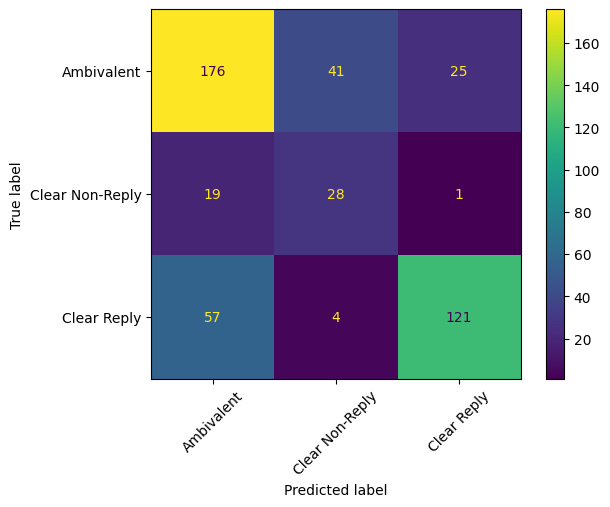

In [18]:
file_path = "clarity_input_ambivalent.jsonl"  # change this to your actual jsonl filename

y_true_clarity = []
y_pred_clarity = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        true_label = row.get("true_label_clarity")
        predicted_label = row.get("predicted_label_clarity")

        # skip broken / unfinished rows
        if true_label is None or predicted_label is None:
            continue

        y_true_clarity.append(true_label)
        y_pred_clarity.append(predicted_label)

print("Total clarity rows:", len(y_true_clarity))

print("\nClarity Macro F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="macro"))

print("\nClarity Weighted F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="weighted"))

print("\nClarity Micro F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="micro"))

print("\nClassification report:")
print(classification_report(y_true_clarity, y_pred_clarity))

labels = ["Ambivalent", "Clear Non-Reply", "Clear Reply"]

cm = confusion_matrix(y_true_clarity, y_pred_clarity, labels=labels)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.show()

In [21]:
prompt_ambivalent = f"""
Task:
    Classify a politician's answer into exactly one of six labels.

    These labels are used when the answer is not a clear explicit answer to the specific_sub_question.

    CLASS_1: Implicit
    - The answer gives enough information to infer the requested information, but does not state it directly.
    - The answer is not explicit, but the requested answer can reasonably be inferred from what is said.

    CLASS_2: Partial/half-answer
    - The answer provides only one part, component, or aspect of the requested information.
    - The answer is relevant, but incomplete.

    CLASS_3: General
    - The answer gives a broad or generic statement instead of the specific information requested.
    - The answer stays on topic but lacks the requested specificity.

    CLASS_4: Dodging
    - The answer avoids giving the requested information while still appearing to respond.
    - The answer may talk around the question, give an unrelated prepared message, or avoid the core issue.

    CLASS_5: Deflection
    - The answer starts on or near the topic but shifts focus to another issue, person, institution, responsibility, or argument.
    - The answer redirects attention away from the specific_sub_question.

    CLASS_6: None of the above
    - The answer does not clearly fit Implicit, Partial/half-answer, General, Dodging, or Deflection.
    - Use this when the answer is unrelated, impossible to classify under these labels, too vague to judge, or belongs to another category not included here.
    - Use this when the answer is actually a clear non-reply such as Declining, Claims ignorance, or Clarification.
    - Use this when the answer is Explicit, because this prompt is not meant to classify explicit answers.

    Rules:
    - Classify the answer only with respect to the specific_sub_question.
    - Choose exactly one class.
    - Use CLASS_6 if none of CLASS_1, CLASS_2, CLASS_3, CLASS_4, or CLASS_5 clearly applies.
    - Do not force an answer into one of the five ambivalent classes.
    - If the answer explicitly gives the requested information, choose CLASS_6.
    - If the answer is a clear non-reply such as Declining, Claims ignorance, or Clarification, choose CLASS_6.
    - If the answer gives enough information to infer the requested answer, choose CLASS_1.
    - If the answer gives only part of the requested information, choose CLASS_2.
    - If the answer is broad but still on topic, choose CLASS_3.
    - If the answer avoids the requested information without clearly shifting blame/topic, choose CLASS_4.
    - If the answer redirects focus to another topic, person, institution, responsibility, or argument, choose CLASS_5.
    - If uncertain between General and Dodging, choose General when the answer is still meaningfully about the asked topic.
    - If uncertain between Dodging and Deflection, choose Deflection only when there is a clear shift of focus.
    - If uncertain between one of the ambivalent classes and None of the above, choose CLASS_6 unless the ambivalent class clearly applies.
    - Return:
        - label: exactly one of CLASS_1, CLASS_2, CLASS_3, CLASS_4, CLASS_5, CLASS_6
        - confidence: an integer from 0 to 100 estimating confidence in the selected label
    - Do not provide an explanation.

    You will receive:
    - original_interview_question
    - specific_sub_question
    - interview_answer
    - gpt3.5_summary
    - affirmative_questions

    Examples:

    original_interview_question: {implicit_examples[0]["interview_question"]}
    specific_sub_question: {implicit_examples[0]["question"]}
    interview_answer: {implicit_examples[0]["interview_answer"]}
    gpt3.5_summary: {implicit_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {implicit_examples[0].get("affirmative_questions", "")}
    Label: CLASS_1

    original_interview_question: {implicit_examples[1]["interview_question"]}
    specific_sub_question: {implicit_examples[1]["question"]}
    interview_answer: {implicit_examples[1]["interview_answer"]}
    gpt3.5_summary: {implicit_examples[1].get("gpt3.5_summary", "")}
    affirmative_questions: {implicit_examples[1].get("affirmative_questions", "")}
    Label: CLASS_1

    original_interview_question: {partial_examples[0]["interview_question"]}
    specific_sub_question: {partial_examples[0]["question"]}
    interview_answer: {partial_examples[0]["interview_answer"]}
    gpt3.5_summary: {partial_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {partial_examples[0].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {partial_examples[1]["interview_question"]}
    specific_sub_question: {partial_examples[1]["question"]}
    interview_answer: {partial_examples[1]["interview_answer"]}
    gpt3.5_summary: {partial_examples[1].get("gpt3.5_summary", "")}
    affirmative_questions: {partial_examples[1].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {general_examples[0]["interview_question"]}
    specific_sub_question: {general_examples[0]["question"]}
    interview_answer: {general_examples[0]["interview_answer"]}
    gpt3.5_summary: {general_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {general_examples[0].get("affirmative_questions", "")}
    Label: CLASS_3

    original_interview_question: {general_examples[1]["interview_question"]}
    specific_sub_question: {general_examples[1]["question"]}
    interview_answer: {general_examples[1]["interview_answer"]}
    gpt3.5_summary: {general_examples[1].get("gpt3.5_summary", "")}
    affirmative_questions: {general_examples[1].get("affirmative_questions", "")}
    Label: CLASS_3

    original_interview_question: {dodging_examples[0]["interview_question"]}
    specific_sub_question: {dodging_examples[0]["question"]}
    interview_answer: {dodging_examples[0]["interview_answer"]}
    gpt3.5_summary: {dodging_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {dodging_examples[0].get("affirmative_questions", "")}
    Label: CLASS_4

    original_interview_question: {dodging_examples[1]["interview_question"]}
    specific_sub_question: {dodging_examples[1]["question"]}
    interview_answer: {dodging_examples[1]["interview_answer"]}
    gpt3.5_summary: {dodging_examples[1].get("gpt3.5_summary", "")}
    affirmative_questions: {dodging_examples[1].get("affirmative_questions", "")}
    Label: CLASS_4

    original_interview_question: {deflection_examples[0]["interview_question"]}
    specific_sub_question: {deflection_examples[0]["question"]}
    interview_answer: {deflection_examples[0]["interview_answer"]}
    gpt3.5_summary: {deflection_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {deflection_examples[0].get("affirmative_questions", "")}
    Label: CLASS_5

    original_interview_question: {deflection_examples[1]["interview_question"]}
    specific_sub_question: {deflection_examples[1]["question"]}
    interview_answer: {deflection_examples[1]["interview_answer"]}
    gpt3.5_summary: {deflection_examples[1].get("gpt3.5_summary", "")}
    affirmative_questions: {deflection_examples[1].get("affirmative_questions", "")}
    Label: CLASS_5
""".strip()

def get_label_ambivalent(class_name: str) -> str:
    labels = {
        "CLASS_1": "Implicit",
        "CLASS_2": "Partial/half-answer",
        "CLASS_3": "General",
        "CLASS_4": "Dodging",
        "CLASS_5": "Deflection",
        "CLASS_6": "None of the above"
    }
    return labels[class_name]
class ClassificationResult_ambivalent(BaseModel):
    label: Literal["CLASS_1", "CLASS_2", "CLASS_3", "CLASS_4", "CLASS_5", "CLASS_6"]
    confidence: int = Field(ge=0, le=100)

In [ ]:
file_path = "clarity.jsonl"
output_file = "ambivalent.jsonl"


client = OpenAI(api_key=api_key)
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        predicted_label = row.get("predicted_label_clarity")

        if predicted_label != "Ambivalent":
            continue

        messages = [
            {
                "role": "developer",
                "content": prompt_ambivalent
            },
            {
                "role": "user",
                "content": f"""
original_interview_question: {row["question"]}
specific_sub_question: {row["specific_sub_question"]}
gpt3.5_summary: {row["gpt3.5_summary"]},
affirmative_questions: {row["affirmative_questions"]},
interview_answer: {row["answer"]}
""".strip()
            }
        ]

        try:
            response = client.responses.parse(
                model="gpt-5.4",
                input=messages,
                text_format=ClassificationResult_ambivalent,
                store=False,
            )

            result = response.output_parsed

            result_label = get_label_ambivalent(result.label)

            if result_label == "None of the above":
                new_predicted_label_clarity = "Ambivalent"
                new_predicted_label_evasion = None
            else:
                new_predicted_label_clarity = "Ambivalent"
                new_predicted_label_evasion = result_label

            saved_result = {
                "dataset_index": row["dataset_index"],
                "question": row["question"],
                "specific_sub_question": row["specific_sub_question"],
                "gpt3.5_summary": row["gpt3.5_summary"],
                "affirmative_questions": row["affirmative_questions"],
                "answer": row["answer"],
                "true_label_evasion": row["true_label_evasion"],
                "true_label_clarity": row["true_label_clarity"],
                "predicted_label_evasion": new_predicted_label_evasion,
                "predicted_label_clarity": new_predicted_label_clarity,
                "confidence": result.confidence
            }
    

            with open(output_file, "a", encoding="utf-8") as file:
                file.write(json.dumps(saved_result, ensure_ascii=False) + "\n")

            print(f"saved dataset index {row['dataset_index']}")

        except Exception as error:
            print(f"Stopped at dataset index {row.get('dataset_index')}: {error}")

saved dataset index 1
saved dataset index 5
saved dataset index 6
saved dataset index 7
saved dataset index 9
saved dataset index 14
saved dataset index 23
saved dataset index 24
saved dataset index 28
saved dataset index 34
saved dataset index 35
saved dataset index 36
saved dataset index 40
saved dataset index 49
saved dataset index 51
saved dataset index 57
saved dataset index 59
saved dataset index 62
saved dataset index 63
saved dataset index 69
saved dataset index 73
saved dataset index 74
saved dataset index 77
saved dataset index 78
saved dataset index 79
saved dataset index 81
saved dataset index 83
saved dataset index 86
saved dataset index 88
saved dataset index 89
saved dataset index 92
saved dataset index 94
saved dataset index 96
saved dataset index 97
saved dataset index 98
saved dataset index 99
saved dataset index 106
saved dataset index 111
saved dataset index 113
saved dataset index 116
saved dataset index 119
saved dataset index 120
saved dataset index 122
saved dat

In [ ]:
prompt_clear_non_reply = f"""
Task:
    Determine whether a politician's answer clearly belongs to one of three target classes.
    If it does not clearly belong to one of them, assign CLASS_4.

    CLASS_1: Declining to answer 
    - Acknowledge the question but directly or indirectly refusing to answer at the moment
    CLASS_2: Claims ignorance 
    - The answerer claims/admits not to know the answer themselves.
    CLASS_3: Clarification 
    - Does not provide the requested information and asks for clarification.
    CLASS_4: None of the above

    Rules:
    - Assign CLASS_1, CLASS_2, or CLASS_3 only when the answer clearly matches that definition.
    - When uncertain between a target class and another type of response, choose CLASS_4.
    - Return:
        - label: exactly one of CLASS_1, CLASS_2, CLASS_3, or CLASS_4
        - confidence: an integer from 0 to 100 estimating confidence in the selected label
    - Do not provide an explanation.

    You will receive:
    - original_interview_question
    - specific_sub_question
    - interview_answer
    - gpt3.5_summary
    - affirmative_questions

    Examples:
    original_interview_question: {declining_examples[0]["interview_question"]}
    specific_sub_question: {declining_examples[0]["question"]}
    interview_answer: {declining_examples[0]["interview_answer"]}
    Label: CLASS_1

    original_interview_question: {declining_examples[1]["interview_question"]}
    specific_sub_question: {declining_examples[1]["question"]}
    interview_answer: {declining_examples[1]["interview_answer"]}
    Label: CLASS_1

    original_interview_question: {ignorance_examples[0]["interview_question"]}
    specific_sub_question: {ignorance_examples[0]["question"]}
    interview_answer: {ignorance_examples[0]["interview_answer"]}
    Label: CLASS_2

    original_interview_question: {ignorance_examples[1]["interview_question"]}
    specific_sub_question: {ignorance_examples[1]["question"]}
    interview_answer: {ignorance_examples[1]["interview_answer"]}
    Label: CLASS_2

    original_interview_question: {clarification_examples[0]["interview_question"]}
    specific_sub_question: {clarification_examples[0]["question"]}
    interview_answer: {clarification_examples[0]["interview_answer"]}
    Label: CLASS_3

    original_interview_question: {clarification_examples[1]["interview_question"]}
    specific_sub_question: {clarification_examples[1]["question"]}
    interview_answer: {clarification_examples[1]["interview_answer"]}
    Label: CLASS_3

    original_interview_question: {explicit_examples[0]["interview_question"]}
    specific_sub_question: {explicit_examples[0]["question"]}
    interview_answer: {explicit_examples[0]["interview_answer"]}
    Label: CLASS_4

    original_interview_question: {general_examples[0]["interview_question"]}
    specific_sub_question: {general_examples[0]["question"]}
    interview_answer: {general_examples[0]["interview_answer"]}
    Label: CLASS_4

    original_interview_question: {partial_examples[0]["interview_question"]}
    specific_sub_question: {partial_examples[0]["question"]}
    interview_answer: {partial_examples[0]["interview_answer"]}
    Label: CLASS_4

    original_interview_question: {dodging_examples[0]["interview_question"]}
    specific_sub_question: {dodging_examples[0]["question"]}
    interview_answer: {dodging_examples[0]["interview_answer"]}
    Label: CLASS_4

    original_interview_question: {deflection_examples[0]["interview_question"]}
    specific_sub_question: {deflection_examples[0]["question"]}
    interview_answer: {deflection_examples[0]["interview_answer"]}
    Label: CLASS_4

    original_interview_question: {implicit_examples[0]["interview_question"]}
    specific_sub_question: {implicit_examples[0]["question"]}
    interview_answer: {implicit_examples[0]["interview_answer"]}
    Label: CLASS_4

""".strip()

def get_label_clear_non(class_name: str) -> str:
    labels = {
        "CLASS_1": "Declining to answer",
        "CLASS_2": "Claims ignorance",
        "CLASS_3": "Clarification",
        "CLASS_4": "None of the above"
    }
    return labels[class_name]

class ClassificationResult_clearnon(BaseModel):
    label: Literal["CLASS_1", "CLASS_2", "CLASS_3", "CLASS_4"]
    confidence: int = Field(ge=0, le=100)

In [ ]:
file_path = "clarity_input_ambivalent.jsonl"
output_file = "non_reply.jsonl"


client = OpenAI(api_key=api_key)
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        predicted_label = row.get("predicted_label_clarity")

        # Only verify examples that were predicted as Clear Reply
        if predicted_label != "Clear Non-Reply":
            continue

        messages = [
            {
                "role": "developer",
                "content": prompt_clear_non_reply
            },
            {
                "role": "user",
                "content": f"""
original_interview_question: {row["question"]}
specific_sub_question: {row["specific_sub_question"]}
gpt3.5_summary: {row["gpt3.5_summary"]},
affirmative_questions: {row["affirmative_questions"]},
interview_answer: {row["answer"]}
""".strip()
            }
        ]

        try:
            response = client.responses.parse(
                model="gpt-5.4",
                input=messages,
                text_format=ClassificationResult_clearnon,
                store=False,
            )

            result = response.output_parsed

            result_label = get_label_clear_non(result.label)

            if result_label == "None of the above":
                new_predicted_label_clarity = "Clear Non-Reply"
                new_predicted_label_evasion = None
            else:
                new_predicted_label_clarity = "Clear Non-Reply"
                new_predicted_label_evasion = result_label

            saved_result = {
                "dataset_index": row["dataset_index"],
                "question": row["question"],
                "specific_sub_question": row["specific_sub_question"],
                "gpt3.5_summary": row["gpt3.5_summary"],
                "affirmative_questions": row["affirmative_questions"],
                "answer": row["answer"],
                "true_label_evasion": row["true_label_evasion"],
                "true_label_clarity": row["true_label_clarity"],
                "predicted_label_evasion": new_predicted_label_evasion,
                "predicted_label_clarity": new_predicted_label_clarity,
                "confidence": result.confidence
            }

            with open(output_file, "a", encoding="utf-8") as file:
                file.write(json.dumps(saved_result, ensure_ascii=False) + "\n")

            print(f"saved dataset index {row['dataset_index']}")

        except Exception as error:
            print(f"Stopped at dataset index {row.get('dataset_index')}: {error}")

saved dataset index 37
saved dataset index 38
saved dataset index 39
saved dataset index 41
saved dataset index 48
saved dataset index 53
saved dataset index 54
saved dataset index 56
saved dataset index 67
saved dataset index 68
saved dataset index 75
saved dataset index 76
saved dataset index 80
saved dataset index 82
saved dataset index 85
saved dataset index 87
saved dataset index 90
saved dataset index 112
saved dataset index 127
saved dataset index 128
saved dataset index 140
saved dataset index 143
saved dataset index 150
saved dataset index 159
saved dataset index 172
saved dataset index 173
saved dataset index 174
saved dataset index 178
saved dataset index 181
saved dataset index 184
saved dataset index 192
saved dataset index 222
saved dataset index 228
saved dataset index 229
saved dataset index 234
saved dataset index 242
saved dataset index 253
saved dataset index 255
saved dataset index 262
saved dataset index 296
saved dataset index 308
saved dataset index 310
saved dat

In [25]:
def load_jsonl(file_path):
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rows.append(json.loads(line))

    return rows


def save_jsonl(rows, output_file):
    with open(output_file, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def combine_results(
    output_non_rep="non_reply.jsonl",
    output_rep="clear_reply.jsonl",
    output_ambi="ambivalent.jsonl",
    output_combined="combined_results.jsonl"
):
    combined = {}

    # 1. Add non-reply rows
    for row in load_jsonl(output_non_rep):
        dataset_index = row.get("dataset_index")
        if dataset_index is not None:
            combined[dataset_index] = row

    # 2. Add clear-reply rows
    for row in load_jsonl(output_rep):
        dataset_index = row.get("dataset_index")
        if dataset_index is not None:
            combined[dataset_index] = row

    # 3. Add ambivalent rows LAST
    # This overwrites clear_reply if dataset_index is the same
    for row in load_jsonl(output_ambi):
        dataset_index = row.get("dataset_index")
        if dataset_index is not None:
            combined[dataset_index] = row

    final_rows = list(combined.values())

    # optional: sort by dataset_index
    final_rows.sort(key=lambda x: x["dataset_index"])

    save_jsonl(final_rows, output_combined)

    print(f"Saved {len(final_rows)} rows to {output_combined}")

    return final_rows

combined_rows = combine_results(
    output_non_rep="non_reply.jsonl",
    output_rep="clear_reply.jsonl",
    output_ambi="ambivalent.jsonl",
    output_combined="combined_results.jsonl"
)


Saved 472 rows to combined_results.jsonl


In [26]:
prompt_all_9 = f"""
Task:
    Classify a politician's answer into exactly one of nine evasion/response labels.

    CLASS_1: Explicit
    - The information requested is explicitly stated (in the requested form)

    CLASS_2: Implicit
    - The information requested is given, but without being explicitly stated (not in the requested form)

    CLASS_3: Partial/half-answer
    - Offers only a specific component of the requested information

    CLASS_4: General
    - The information provided is too general/lacks the requested specificity

    CLASS_5: Dodging
    - Ignoring the question altogether

    CLASS_6: Deflection
    - Starts on topic but shifts the focus and makes a different point than what is asked

    CLASS_7: Declining to answer
    - Acknowledge the question but directly or indirectly refusing to answer at the moment

    CLASS_8: Claims ignorance
    - The answerer claims/admits not to know the answer themselves

    CLASS_9: Clarification
    - Does not provide the requested information and asks for clarification
    
    Rules:
    - Classify the answer only with respect to the specific_sub_question.
    - Choose exactly one class.
    - Return:
        - label: exactly one of CLASS_1, CLASS_2, CLASS_3, CLASS_4, CLASS_5, CLASS_6, CLASS_7, CLASS_8, or CLASS_9
        - confidence: an integer from 0 to 100 estimating confidence in the selected label
    - Do not provide an explanation.

    You will receive:
    - original_interview_question
    - specific_sub_question
    - interview_answer
    - gpt3.5_summary
    - affirmative_questions

    Examples:

    original_interview_question: {explicit_examples[0]["interview_question"]}
    specific_sub_question: {explicit_examples[0]["question"]}
    interview_answer: {explicit_examples[0]["interview_answer"]}
    gpt3.5_summary: {explicit_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {explicit_examples[0].get("affirmative_questions", "")}
    Label: CLASS_1

    original_interview_question: {implicit_examples[0]["interview_question"]}
    specific_sub_question: {implicit_examples[0]["question"]}
    interview_answer: {implicit_examples[0]["interview_answer"]}
    gpt3.5_summary: {implicit_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {implicit_examples[0].get("affirmative_questions", "")}
    Label: CLASS_2

    original_interview_question: {partial_examples[0]["interview_question"]}
    specific_sub_question: {partial_examples[0]["question"]}
    interview_answer: {partial_examples[0]["interview_answer"]}
    gpt3.5_summary: {partial_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {partial_examples[0].get("affirmative_questions", "")}
    Label: CLASS_3

    original_interview_question: {general_examples[0]["interview_question"]}
    specific_sub_question: {general_examples[0]["question"]}
    interview_answer: {general_examples[0]["interview_answer"]}
    gpt3.5_summary: {general_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {general_examples[0].get("affirmative_questions", "")}
    Label: CLASS_4

    original_interview_question: {dodging_examples[0]["interview_question"]}
    specific_sub_question: {dodging_examples[0]["question"]}
    interview_answer: {dodging_examples[0]["interview_answer"]}
    gpt3.5_summary: {dodging_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {dodging_examples[0].get("affirmative_questions", "")}
    Label: CLASS_5

    original_interview_question: {deflection_examples[0]["interview_question"]}
    specific_sub_question: {deflection_examples[0]["question"]}
    interview_answer: {deflection_examples[0]["interview_answer"]}
    gpt3.5_summary: {deflection_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {deflection_examples[0].get("affirmative_questions", "")}
    Label: CLASS_6

    original_interview_question: {declining_examples[0]["interview_question"]}
    specific_sub_question: {declining_examples[0]["question"]}
    interview_answer: {declining_examples[0]["interview_answer"]}
    gpt3.5_summary: {declining_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {declining_examples[0].get("affirmative_questions", "")}
    Label: CLASS_7

    original_interview_question: {ignorance_examples[0]["interview_question"]}
    specific_sub_question: {ignorance_examples[0]["question"]}
    interview_answer: {ignorance_examples[0]["interview_answer"]}
    gpt3.5_summary: {ignorance_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {ignorance_examples[0].get("affirmative_questions", "")}
    Label: CLASS_8

    original_interview_question: {clarification_examples[0]["interview_question"]}
    specific_sub_question: {clarification_examples[0]["question"]}
    interview_answer: {clarification_examples[0]["interview_answer"]}
    gpt3.5_summary: {clarification_examples[0].get("gpt3.5_summary", "")}
    affirmative_questions: {clarification_examples[0].get("affirmative_questions", "")}
    Label: CLASS_9
""".strip()

def get_label_all9(class_name: str) -> str:
    labels = {
        "CLASS_1": "Explicit",
        "CLASS_2": "Implicit",
        "CLASS_3": "Partial/half-answer",
        "CLASS_4": "General",
        "CLASS_5": "Dodging",
        "CLASS_6": "Deflection",
        "CLASS_7": "Declining to answer",
        "CLASS_8": "Claims ignorance",
        "CLASS_9": "Clarification",
    }
    return labels[class_name]
class ClassificationResult_all9(BaseModel):
    label: Literal["CLASS_1", "CLASS_2", "CLASS_3", "CLASS_4", "CLASS_5", "CLASS_6", "CLASS_7", "CLASS_8", "CLASS_9"]
    confidence: int = Field(ge=0, le=100)


In [ ]:
file_path = "combined_results.jsonl"
output_file = "9_prompts.jsonl"

label_ambi=["Implicit","Partial/half-answer","General","Dodging","Deflection"]
label_no=["Declining to answer","Claims ignorance","Clarification"]



client = OpenAI(api_key=api_key)
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        predicted_label = row.get("predicted_label_evasion")

        if predicted_label != None:
            continue

        messages = [
            {
                "role": "developer",
                "content": prompt_all_9
            },
            {
                "role": "user",
                "content": f"""
original_interview_question: {row["question"]}
specific_sub_question: {row["specific_sub_question"]}
gpt3.5_summary: {row["gpt3.5_summary"]},
affirmative_questions: {row["affirmative_questions"]},
interview_answer: {row["answer"]}
""".strip()
            }
        ]

        try:
            response = client.responses.parse(
                model="gpt-5.4",
                input=messages,
                text_format=ClassificationResult_all9,
                store=False,
            )

            result = response.output_parsed

            result_label = get_label_all9(result.label)
            new_predicted_label_evasion=result_label
            if result_label in label_ambi:
                new_predicted_label_clarity="Ambivalent"
            elif result_label in label_no:
                new_predicted_label_clarity="Clear Non-Reply"
            else:
                new_predicted_label_clarity="Clear Reply"

            saved_result = {
                "dataset_index": row["dataset_index"],
                "question": row["question"],
                "specific_sub_question": row["specific_sub_question"],
                "gpt3.5_summary": row["gpt3.5_summary"],
                "affirmative_questions": row["affirmative_questions"],
                "answer": row["answer"],
                "true_label_evasion": row["true_label_evasion"],
                "true_label_clarity": row["true_label_clarity"],
                "predicted_label_evasion": new_predicted_label_evasion,
                "predicted_label_clarity": new_predicted_label_clarity,
                "confidence": result.confidence
            }

            with open(output_file, "a", encoding="utf-8") as file:
                file.write(json.dumps(saved_result, ensure_ascii=False) + "\n")

            print(f"saved dataset index {row['dataset_index']}")

        except Exception as error:
            print(f"Stopped at dataset index {row.get('dataset_index')}: {error}")

saved dataset index 13
saved dataset index 42
saved dataset index 48
saved dataset index 50
saved dataset index 53
saved dataset index 54
saved dataset index 56
saved dataset index 67
saved dataset index 68
saved dataset index 70
saved dataset index 71
saved dataset index 75
saved dataset index 76
saved dataset index 80
saved dataset index 82
saved dataset index 85
saved dataset index 91
saved dataset index 98
saved dataset index 107
saved dataset index 115
saved dataset index 138
saved dataset index 140
saved dataset index 143
saved dataset index 148
saved dataset index 151
saved dataset index 159
saved dataset index 171
saved dataset index 178
saved dataset index 181
saved dataset index 184
saved dataset index 195
saved dataset index 216
saved dataset index 217
saved dataset index 227
saved dataset index 230
saved dataset index 242
saved dataset index 247
saved dataset index 253
saved dataset index 262
saved dataset index 267
saved dataset index 269
saved dataset index 271
saved data

In [28]:

def load_jsonl(file_path):
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rows.append(json.loads(line))

    return rows


def save_jsonl(rows, output_path):
    with open(output_path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def combine_take_output_file_on_duplicate(
    file_path="combined_results.jsonl",
    output_file="9_prompts.jsonl",
    final_output_file="final_combined_results.jsonl"
):
    combined = {}

    # First add rows from combined_results.jsonl
    for row in load_jsonl(file_path):
        dataset_index = row.get("dataset_index")

        if dataset_index is None:
            continue

        combined[dataset_index] = row

    # Then add rows from 9_prompts.jsonl
    # If dataset_index already exists, this overwrites it
    for row in load_jsonl(output_file):
        dataset_index = row.get("dataset_index")

        if dataset_index is None:
            continue

        combined[dataset_index] = row

    final_rows = list(combined.values())
    final_rows.sort(key=lambda x: x["dataset_index"])

    save_jsonl(final_rows, final_output_file)

    print(f"Saved {len(final_rows)} rows to {final_output_file}")

    return final_rows
final_rows = combine_take_output_file_on_duplicate(
    file_path="combined_results.jsonl",
    output_file="9_prompts.jsonl",
    final_output_file="final_combined_results.jsonl"
)

Saved 472 rows to final_combined_results.jsonl


Total clarity rows: 472

Clarity Macro F1:
0.7198032078892274

Clarity Weighted F1:
0.7494779650758778

Clarity Micro F1:
0.75

Classification report:
                 precision    recall  f1-score   support

     Ambivalent       0.74      0.81      0.77       242
Clear Non-Reply       0.63      0.65      0.64        48
    Clear Reply       0.80      0.70      0.75       182

       accuracy                           0.75       472
      macro avg       0.73      0.72      0.72       472
   weighted avg       0.75      0.75      0.75       472

[[196  17  29]
 [ 15  31   2]
 [ 54   1 127]]


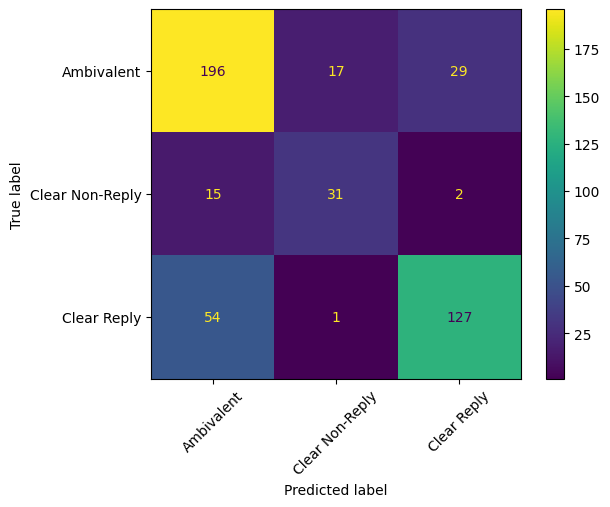

In [29]:
import json
from sklearn.metrics import f1_score, classification_report

file_path = "final_combined_results.jsonl"  # change this to your actual jsonl filename

y_true_clarity = []
y_pred_clarity = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        true_label = row.get("true_label_clarity")
        predicted_label = row.get("predicted_label_clarity")

        # skip broken / unfinished rows
        if true_label is None or predicted_label is None:
            continue

        y_true_clarity.append(true_label)
        y_pred_clarity.append(predicted_label)

print("Total clarity rows:", len(y_true_clarity))

print("\nClarity Macro F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="macro"))

print("\nClarity Weighted F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="weighted"))

print("\nClarity Micro F1:")
print(f1_score(y_true_clarity, y_pred_clarity, average="micro"))

print("\nClassification report:")
print(classification_report(y_true_clarity, y_pred_clarity))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Ambivalent", "Clear Non-Reply", "Clear Reply"]

cm = confusion_matrix(y_true_clarity, y_pred_clarity, labels=labels)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.show()

Total evasion rows: 472

Evasion Macro F1:
0.43409358762942163

Evasion Weighted F1:
0.5075387383213888

Evasion Micro F1:
0.4957627118644068

Classification report:
                     precision    recall  f1-score   support

           Explicit       0.80      0.70      0.75       182
           Implicit       0.21      0.37      0.27        51
Partial/half-answer       0.17      0.22      0.19        18
            General       0.26      0.40      0.31        35
            Dodging       0.47      0.37      0.41        92
         Deflection       0.32      0.17      0.23        46
Declining to answer       0.56      0.56      0.56        18
   Claims ignorance       0.67      0.40      0.50        20
      Clarification       0.53      1.00      0.69        10

           accuracy                           0.50       472
          macro avg       0.44      0.47      0.43       472
       weighted avg       0.54      0.50      0.51       472


Confusion matrix:
[[127  28   9   9  

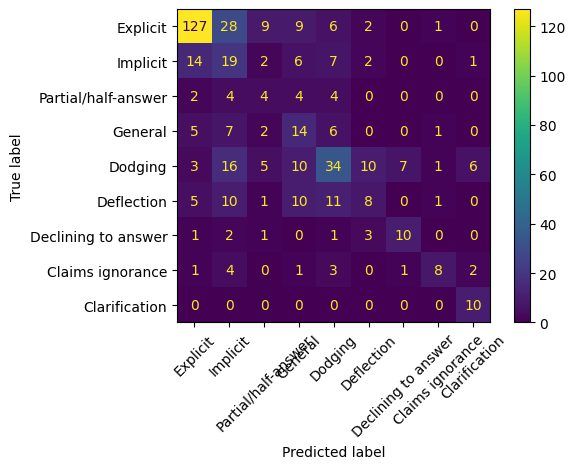

In [30]:

file_path = "final_combined_results.jsonl"

class_to_label = {
    "CLASS_1": "Explicit",
    "CLASS_2": "Implicit",
    "CLASS_3": "Partial/half-answer",
    "CLASS_4": "General",
    "CLASS_5": "Dodging",
    "CLASS_6": "Deflection",
    "CLASS_7": "Declining to answer",
    "CLASS_8": "Claims ignorance",
    "CLASS_9": "Clarification",
}

labels = [
    "Explicit",
    "Implicit",
    "Partial/half-answer",
    "General",
    "Dodging",
    "Deflection",
    "Declining to answer",
    "Claims ignorance",
    "Clarification",
]

y_true_evasion = []
y_pred_evasion = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        row = json.loads(line)

        true_label = row.get("true_label_evasion")
        predicted_label = row.get("predicted_label_evasion")

        if true_label is None or predicted_label is None:
            continue

        # convert CLASS_X to text label if needed
        if true_label in class_to_label:
            true_label = class_to_label[true_label]

        if predicted_label in class_to_label:
            predicted_label = class_to_label[predicted_label]

        y_true_evasion.append(true_label)
        y_pred_evasion.append(predicted_label)

print("Total evasion rows:", len(y_true_evasion))

print("\nEvasion Macro F1:")
print(f1_score(y_true_evasion, y_pred_evasion, average="macro", labels=labels))

print("\nEvasion Weighted F1:")
print(f1_score(y_true_evasion, y_pred_evasion, average="weighted", labels=labels))

print("\nEvasion Micro F1:")
print(f1_score(y_true_evasion, y_pred_evasion, average="micro", labels=labels))

print("\nClassification report:")
print(classification_report(y_true_evasion, y_pred_evasion, labels=labels))

cm = confusion_matrix(y_true_evasion, y_pred_evasion, labels=labels)

print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()